# Prompt Visualization

Notebook started by Katy to make visuals for the AI for Oncology presentation 

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/bhklab-nninteractive


In [23]:
from damply import dirs
from pathlib import Path
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

from readii.image_processing import displayCTSegOverlay, displayImageSlice
from workflow.scripts.utils.prompts import get_prompt_points
from workflow.scripts.utils.masks import find_max_area_slice
from workflow.scripts.utils.scans import choose_windowing

In [4]:
def load_and_flip_image(image_path: Path) -> np.ndarray:
    image = sitk.ReadImage(image_path)
    image_arr = sitk.GetArrayFromImage(image)
    flipped_image_arr = np.flip(image_arr, axis=1)
    return flipped_image_arr

In [24]:
dataset = "CVPR_LesionLocator"

# Lung example = 2013 = MSD_lung_026
sample_id = "2013"
window_l, window_w = choose_windowing('lung')

# Abdomen example = 0001 = KiTS23_case_00000
# sample_id = "0001"
# window_l, window_w = choose_windowing('abdomen')

In [17]:
# baseline images
b_scan_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
b_mask_path = dirs.PROCDATA / dataset / "images" / "Baseline" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

# synthetic follow-up images
f_scan_path = dirs.PROCDATA / dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "CT.nii.gz"
f_mask_path = dirs.PROCDATA/ dataset / "images" / "Synthetic_Follow_Up" / f"LesionLocator_{sample_id}" / "mask_1.nii.gz"

b_scan = sitk.DICOMOrient(sitk.ReadImage(b_scan_path), 'LPS')
b_mask = sitk.DICOMOrient(sitk.ReadImage(b_mask_path), 'LPS')
# f_scan = load_and_flip_image(f_scan_path)
# f_mask = load_and_flip_image(f_mask_path)

In [30]:
max_area_slice_idx = find_max_area_slice(sitk.GetArrayFromImage(b_mask))
max_area_slice_arr = sitk.GetArrayFromImage(b_mask)[max_area_slice_idx,:,:]

<Axes: >

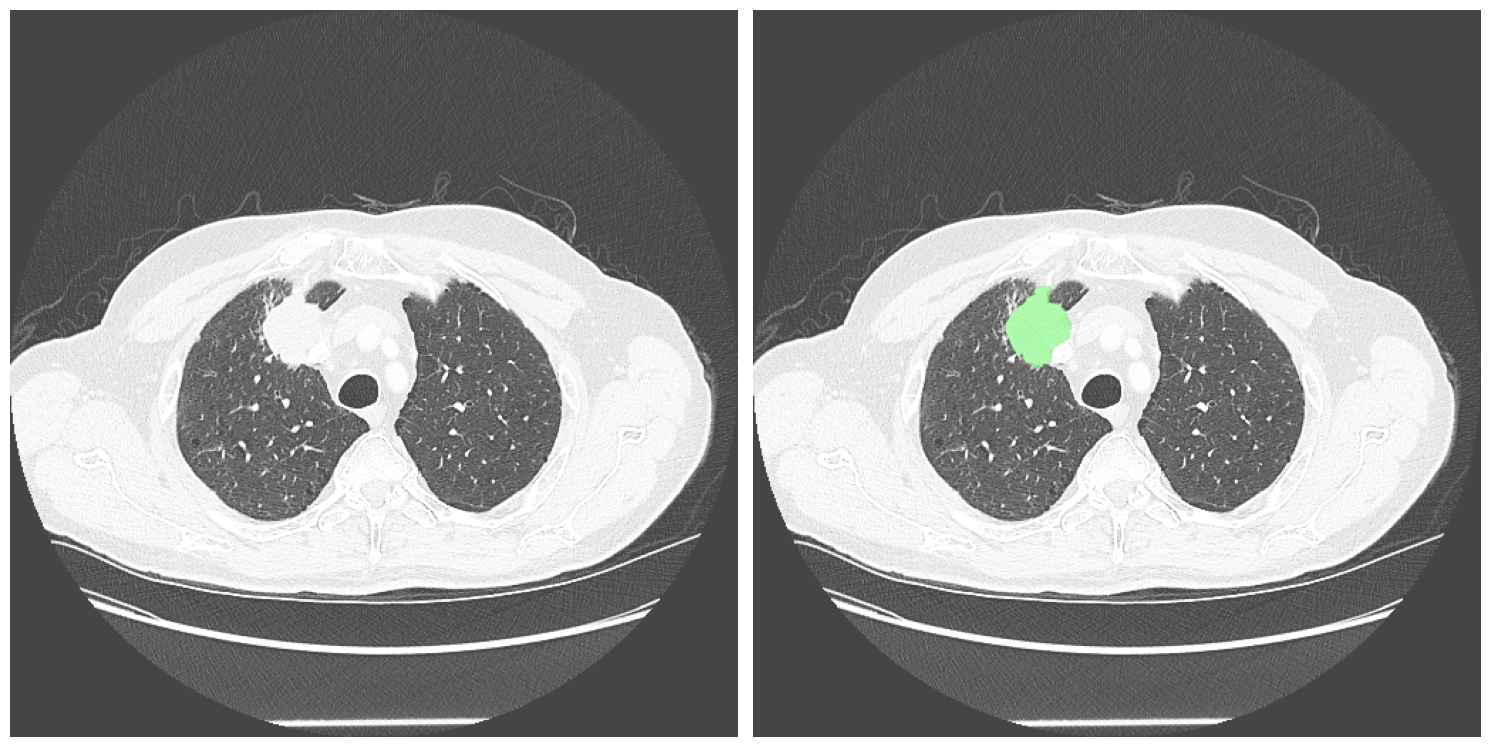

In [29]:
fig_slice, ax_slice = plt.subplots(1, 2, figsize=(15, 8), layout="tight")

dispMin = window_l - (window_w / 2)
dispMax = window_l + (window_w / 2)

displayCTSegOverlay(b_scan, b_mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0, ax=ax_slice[0])
displayCTSegOverlay(b_scan, b_mask, max_area_slice_idx, dispMax=dispMax, dispMin=dispMin, alpha=0.3, ax=ax_slice[1])

In [31]:
neg_pts, center_pt, recist_pts, recist_iqr_pts, _major_axis_length = get_prompt_points(max_area_slice_arr, b_mask)

TypeError: get_prompt_points() missing 1 required positional argument: 'spacing'